# STEP 1

In [2]:
from sklearn.datasets import load_iris 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


load_iris → Loads the famous Iris dataset (flower dataset with 150 samples, 3 species).

train_test_split → Splits dataset into training and testing sets.

KNeighborsClassifier → Machine learning model (KNN algorithm).

accuracy_score → Calculates how accurate predictions are.

classification_report → Gives precision, recall, f1-score (not used in this code but imported).

# STEP 2

In [ ]:

iris = load_iris ()
x = iris.data
y = iris.target

Loads the Iris dataset.

iris.data = features (sepal length, sepal width, petal length, petal width). Shape: (150, 4).

iris.target = labels (0 = setosa, 1 = versicolor, 2 = virginica).

# STEP 3

In [ ]:

# spliting data into training data set and testing data set
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3)

1. Inputs

x → Features (150 samples × 4 features in Iris).

y → Labels (150 values → 0, 1, or 2 for species).

test_size=0.3 → We want 30% of samples (45) for testing and 70% (105) for training.

2. Shuffling the Data

By default, train_test_split shuffles the dataset before splitting.

Why?
If we don’t shuffle, the Iris dataset comes ordered:

First 50 = Setosa

Next 50 = Versicolor

Last 50 = Virginica

If you split without shuffling, your training set might only get one class and the test set another → bad!

So internally:

It creates a list of indices [0, 1, 2, …, 149].

Shuffles them randomly.

3. Splitting into Train and Test

After shuffling, sklearn calculates split sizes:

n_test = int(0.3 * 150) = 45

n_train = 150 - 45 = 105

First 105 indices → X_train, y_train

Remaining 45 indices → X_test, y_test

4. Returns

X_train = features for training (shape: 105 × 4)

X_test = features for testing (shape: 45 × 4)

y_train = labels for training (105 values)

y_test = labels for testing (45 values)

⚡ Behind the scenes (simplified pseudo-code)

Here’s what sklearn does internally (simplified):

import numpy as np

def train_test_split(x, y, test_size=0.3, random_state=None):
    n_samples = len(x)   # 150 for iris
    n_test = int(n_samples * test_size)  # 45
    n_train = n_samples - n_test         # 105

    indices = np.arange(n_samples)       # [0..149]
    np.random.shuffle(indices)           # shuffle randomly

    train_idx = indices[:n_train]        # first 105 shuffled indices
    test_idx  = indices[n_train:]        # last 45 shuffled indices

    return x[train_idx], x[test_idx], y[train_idx], y[test_idx]


✅ So in short:

It shuffles data.

Splits into train (70%) and test (30%).

Returns those 4 arrays

# STEP 4

In [ ]:

# instantiate the k - nn classifier
k = 3
kmn = KNeighborsClassifier(n_neighbors=k)

Sets k = 3 → classifier will look at the 3 nearest neighbors to classify a sample.

KNeighborsClassifier(n_neighbors=k) → Creates KNN model.

# STEP 5

In [ ]:

# traing the classifier
kmn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

.fit() trains the model using training data (X_train, y_train).


# STEP 6

In [ ]:

# make predictions
y_pred = kmn.predict(x_test)



Predicts labels for test data (X_test).

Stores results in y_pred.

# STEP 7

In [ ]:

# to calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy * 100:.2f}%\n")


Accuracy:95.56%



This part comes from Python f-strings (formatted strings):

print(f"Accuracy: {accuracy * 100:.2f}%")


👉 The .2f means:

f → format as a floating-point number (decimal).

.2 → keep only 2 digits after the decimal point.

Example:
value = 0.856734
print(f"{value:.2f}")


Output → 0.86 ✅ (rounded to 2 decimal places)

value = 0.856734
print(f"{value:.4f}")


Output → 0.8567 ✅ (4 decimals)

So in your case:

If accuracy = 0.9666 → accuracy*100 = 96.666…

With .2f → it prints 96.67%

⚡ In short: .2f = round number to 2 decimal places when printing.
1. What is accuracy?

Accuracy =

Number of correct predictions
Total predictions
Total predictions
Number of correct predictions
	​


Example:

Suppose y_test = [0,1,2,1,0] (actual answers)

And y_pred = [0,1,0,1,0] (model’s answers)

Correct ones = 4 (out of 5).
So accuracy = 4/5 = 0.8 (or 80%).

2. accuracy_score(y_test, y_pred)

This function checks each predicted value vs actual value and counts how many are correct.

Returns a number between 0.0 and 1.0.

Example: if 80% correct → it gives 0.8.

3. Why accuracy * 10? ⚠️⚠️⚠️⚠️ dont worry i am sumit i do this initially made this mmistake for my understanding 

This is likely a mistake in your code.

Normally, we multiply by 100 to convert to percentage.

If accuracy = 0.8

accuracy * 100 = 80.00 → ✅ correct percentage

accuracy * 10 = 8.00 → ❌ wrong (it will print 8% instead of 80%)

So the correct line should be:

print(f"Accuracy: {accuracy * 100:.2f}%\n")


✅ Simplified:

accuracy_score counts how many predictions are right.

Divides by total predictions.

You multiply by 100 to show it as a percentage.

# STEP 8

In [ ]:

# to correct and incorrect predictions

for i in range(len(y_test)):
    if y_test[i] == y_pred[i]:
        print(f"correct : predict = {y_pred[i]}, Actual = {y_test[i]}")
    else:
        print(f"Incorrect : predict = {y_pred[i]}, Actual = {y_test[i]}")

correct : predict = 2, Actual = 2
correct : predict = 1, Actual = 1
correct : predict = 2, Actual = 2
correct : predict = 0, Actual = 0
correct : predict = 0, Actual = 0
correct : predict = 2, Actual = 2
Incorrect : predict = 1, Actual = 2
correct : predict = 0, Actual = 0
correct : predict = 2, Actual = 2
correct : predict = 0, Actual = 0
correct : predict = 0, Actual = 0
correct : predict = 2, Actual = 2
correct : predict = 1, Actual = 1
correct : predict = 2, Actual = 2
correct : predict = 1, Actual = 1
correct : predict = 0, Actual = 0
correct : predict = 1, Actual = 1
correct : predict = 1, Actual = 1
correct : predict = 0, Actual = 0
correct : predict = 2, Actual = 2
correct : predict = 1, Actual = 1
correct : predict = 2, Actual = 2
correct : predict = 0, Actual = 0
correct : predict = 1, Actual = 1
correct : predict = 1, Actual = 1
correct : predict = 0, Actual = 0
correct : predict = 2, Actual = 2
correct : predict = 0, Actual = 0
correct : predict = 0, Actual = 0
correct : pr

Loops through all test samples.

If prediction matches actual label → prints "Correct".

Else → prints "Incorrect".


🧠 What it means in very simple words

Imagine you gave a test paper to your model.

y_test = the answer key (actual correct answers).

y_pred = the student’s answers (model’s predictions).

Now, this loop is checking answers one by one:

Look at each question (each index i).

If student’s answer = correct answer → print "Correct".

Otherwise → print "Incorrect".

That’s all ✅

📌 Example

Suppose:

y_test = [0, 1, 2, 1]
y_pred = [0, 0, 2, 1]


Step by step:

i=0 → (Actual=0, Predicted=0) → ✅ Correct

i=1 → (Actual=1, Predicted=0) → ❌ Incorrect

i=2 → (Actual=2, Predicted=2) → ✅ Correct

i=3 → (Actual=1, Predicted=1) → ✅ Correct

Output:

Correct : Predicted = 0, Actual = 0
Incorrect : Predicted = 0, Actual = 1
Correct : Predicted = 2, Actual = 2
Correct : Predicted = 1, Actual = 1

⚙️ Backend mechanism

When Python runs this:

len(y_test) → finds how many test samples there are (say 45).

range(len(y_test)) → creates numbers from 0 to 44.

for i in ... → loop goes through each number i.

i=0, i=1, i=2 … until i=44.

y_test[i] → takes the actual label at index i.

y_pred[i] → takes the predicted label at index i.

if y_test[i] == y_pred[i] → compares them:

If equal → print Correct

Else → print Incorrect

Loop continues until all are checked.

# STEP 9

# visualization

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 10

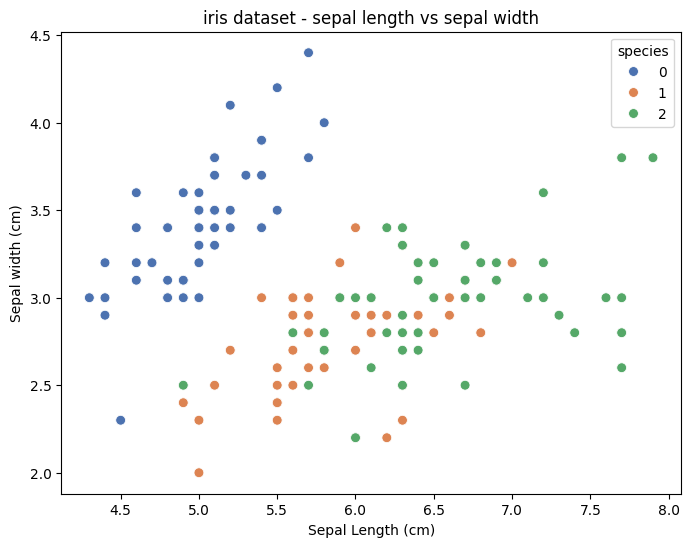

In [ ]:

# to visualize eith the sepal length and width as features
plt.figure(figsize=(8,6))
#sns.scatterplot(x=x[:0], y=x[:,1], s=50)
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=50, palette="deep")

plt.title("iris dataset - sepal length vs sepal width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal width (cm)")
plt.legend(title = "species")
plt.show()
